In [1]:
from scoresbibm.src.tasks.all_conditional_tasks import TwoMoonsAllConditionalTask, SLCPAllConditionalTask, NonlinearGaussianTreeAllConditionalTask, NonlinearMarcovChainAllConditionalTask
from scoresbibm.src.tasks.sbibm_tasks import TwoMoons, SBIBMTask
from scoresbibm.src.tasks.base_task import InferenceTask, Task, AllConditionalTask

import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

In [22]:
#task = TwoMoonsAllConditionalTask()
#task = SLCPAllConditionalTask()
#task = NonlinearMarcovChainAllConditionalTask()
task = NonlinearGaussianTreeAllConditionalTask()

In [23]:
dim = jax.tree_util.tree_reduce(lambda x, y: x + y, task.var_sizes)

In [24]:
base_mask_fn = task.get_base_mask_fn()
node_id = jnp.arange(dim)

In [25]:
from probjax.utils.graph import min_faithfull_mask, faithfull_mask

[8 8 8 8 2 2 2]
[8 8 8 8 0 0 0]
Frontal set:  [False False False False  True  True  True]
Marked:  [False False False False False False False]
Selected:  6
[8 8 8 8 2 2 8]
[8 8 8 8 0 0 8]
Frontal set:  [False False False False  True  True False]
Marked:  [False False False False False False  True]
Selected:  5
[8 8 8 8 2 8 8]
[8 8 8 8 0 8 8]
Frontal set:  [False False False False  True False False]
Marked:  [False False False False False  True  True]
Selected:  4
[8 4 8 8 8 8 8]
[8 0 8 8 8 8 8]
Frontal set:  [False  True False False False False False]
Marked:  [False False False False  True  True  True]
Selected:  1
[4 8 8 8 8 8 8]
[0 8 8 8 8 8 8]
Frontal set:  [ True False False False False False False]
Marked:  [False  True False False  True  True  True]
Selected:  0
[False False  True  True False False False]


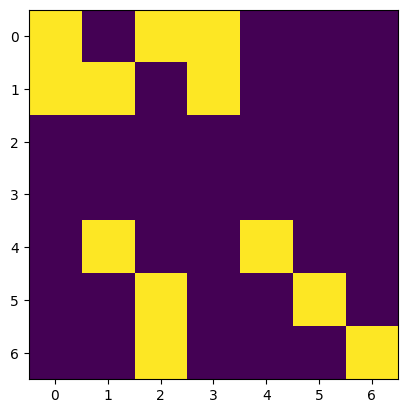

In [27]:
base_mask = base_mask_fn(node_id, None)
#condition_mask = jnp.array([1]*2 + [0]*6+ [0]*2 + [0]*5 + [1]*5, dtype=bool)
condition_mask = jax.random.bernoulli(jax.random.PRNGKey(2), p=0.1, shape=(dim,)).astype(bool)
with jax.disable_jit():
    mask = min_faithfull_mask(base_mask,condition_mask, conditioned_nodes="removed",top_mode=0)
print(condition_mask)
plt.imshow(mask)

[ True  True False False False False False False False False False False
 False False False  True  True  True  True  True]


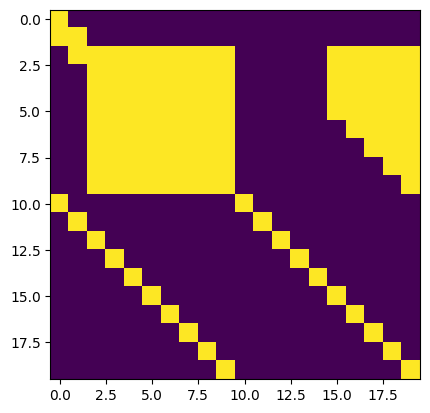

In [21]:
base_mask = base_mask_fn(node_id, None)
condition_mask = jnp.array([1]*2 + [0]*6+ [0]*2 + [0]*5 + [1]*5, dtype=bool)
#condition_mask = jax.random.bernoulli(jax.random.PRNGKey(2), p=0.1, shape=(dim,)).astype(bool)
mask = faithfull_mask(base_mask,condition_mask)
print(condition_mask)
plt.imshow(mask)

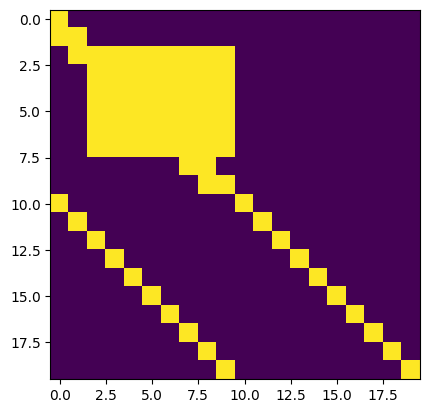

In [14]:
plt.imshow(mask)

In [6]:
reference_sampler = task.get_reference_sampler()

In [7]:
# Two moons
theta, x = task.get_thetas_xs(1, rng=jax.random.PRNGKey(0))
theta_dim = theta.shape[-1]
x_dim = x.shape[-1]
print(x_dim, theta_dim)
samples = reference_sampler.sample(2000,x_o = x[0], condition_mask=jnp.array([0]*theta_dim + [1] * x_dim), rng=jax.random.PRNGKey(0))

2 2


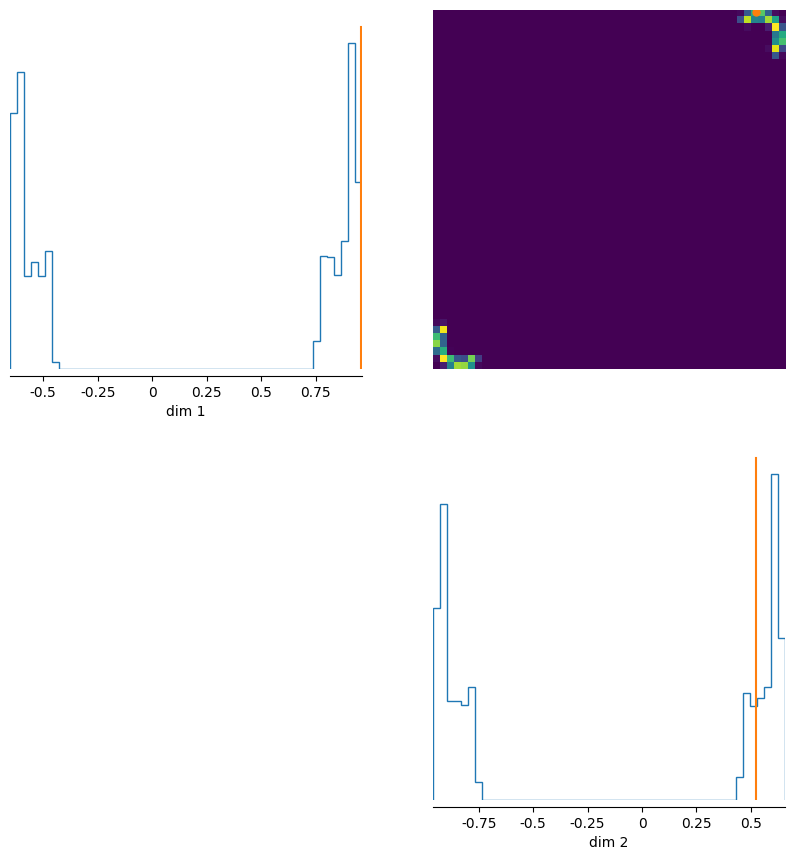

In [8]:
import matplotlib.pyplot as plt 
import seaborn as sns
from sbi.analysis import pairplot
import numpy as np

_ = pairplot(np.array(samples), points=np.array(theta[0]))

[False  True  True  True] [ 0.696 -0.066  0.711] [-0.186]


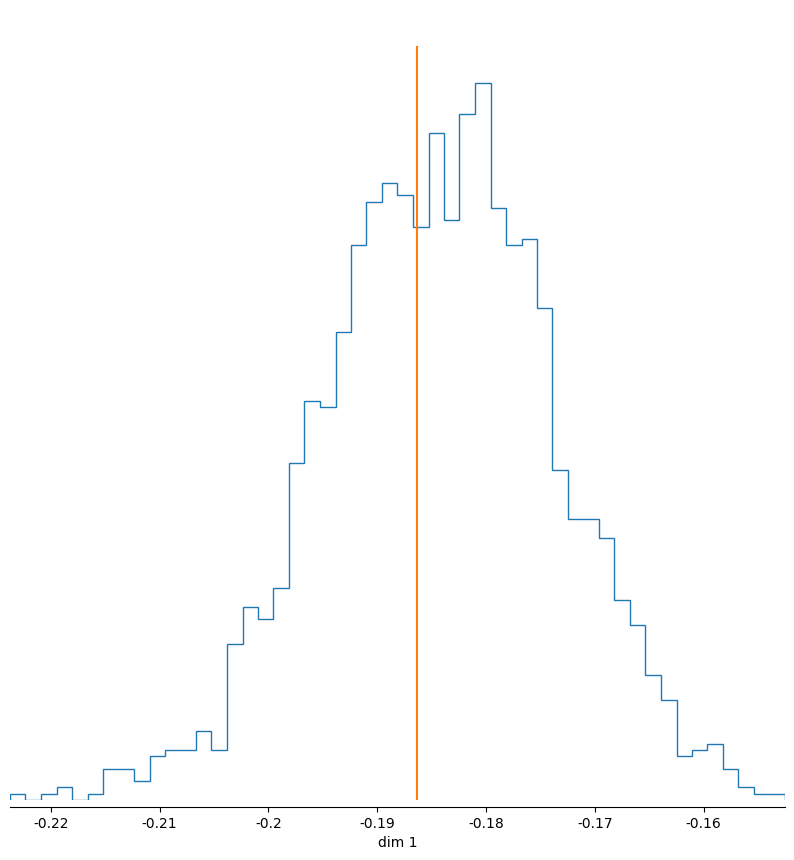

[False  True False  True] [-0.732 -0.17 ] [-0.61  -0.662]


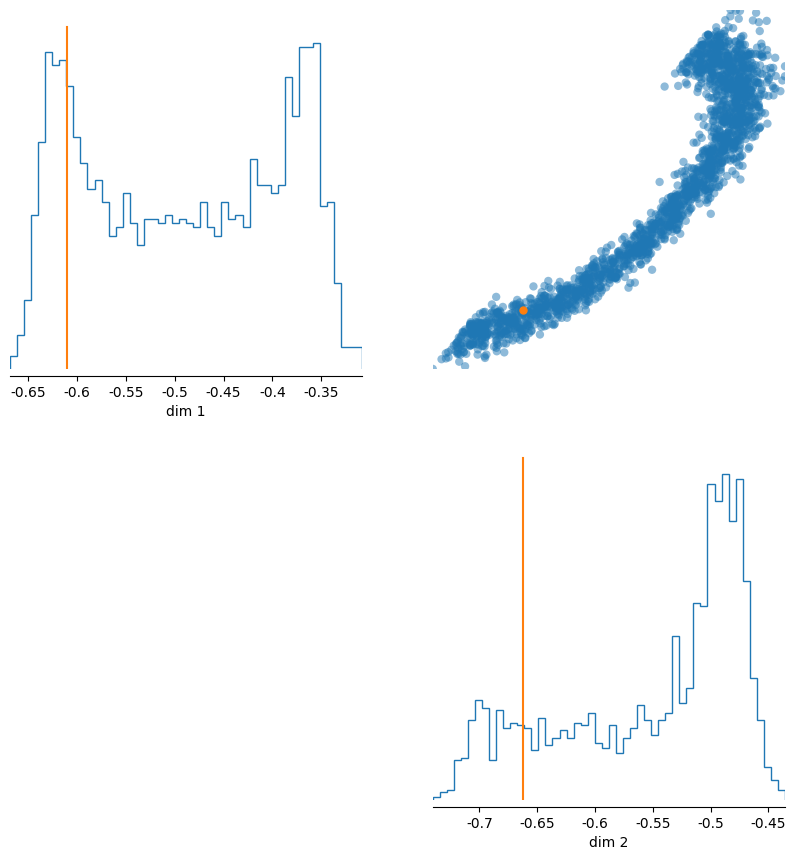

[ True False False  True] [-0.017  0.219] [0.241 0.185]


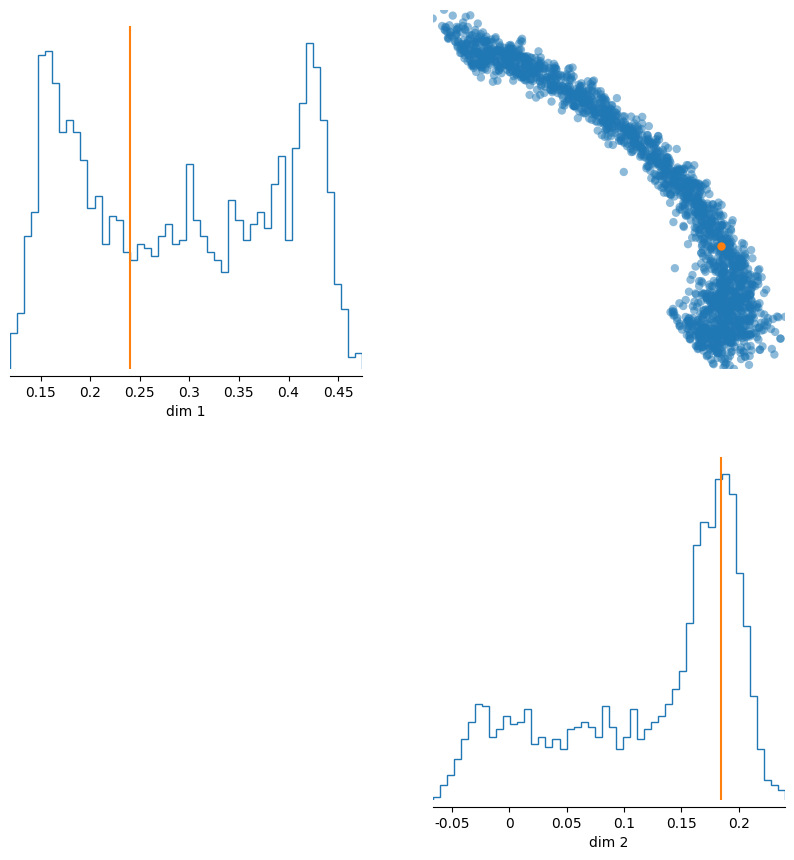

[False False False  True] [-0.596] [ 0.579 -0.213  0.093]


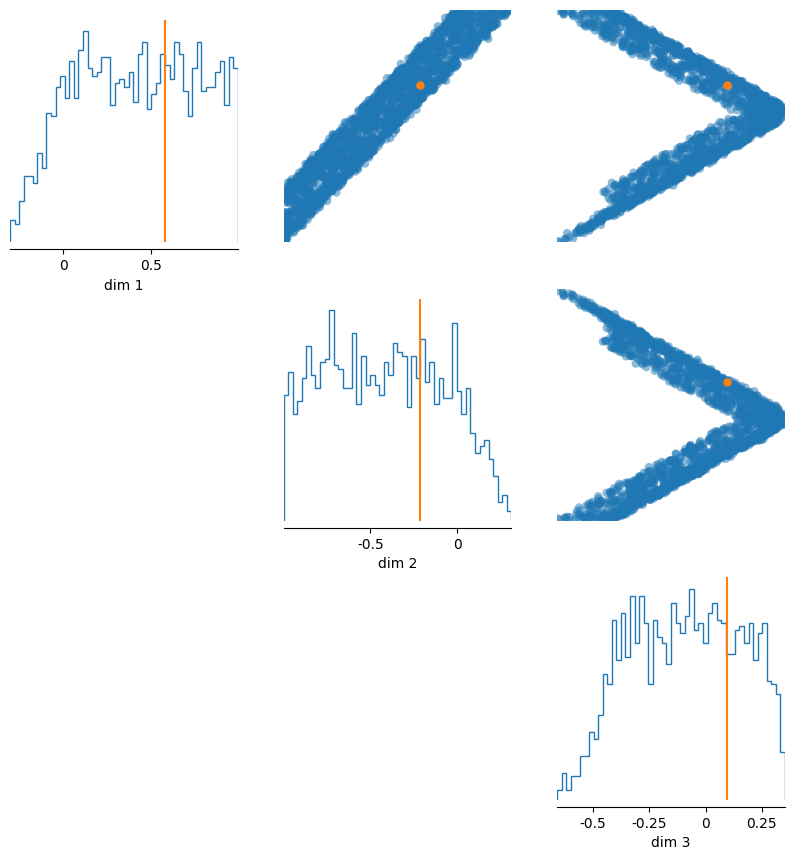

[ True  True False  True] [ 0.453  0.027 -0.297] [0.017]


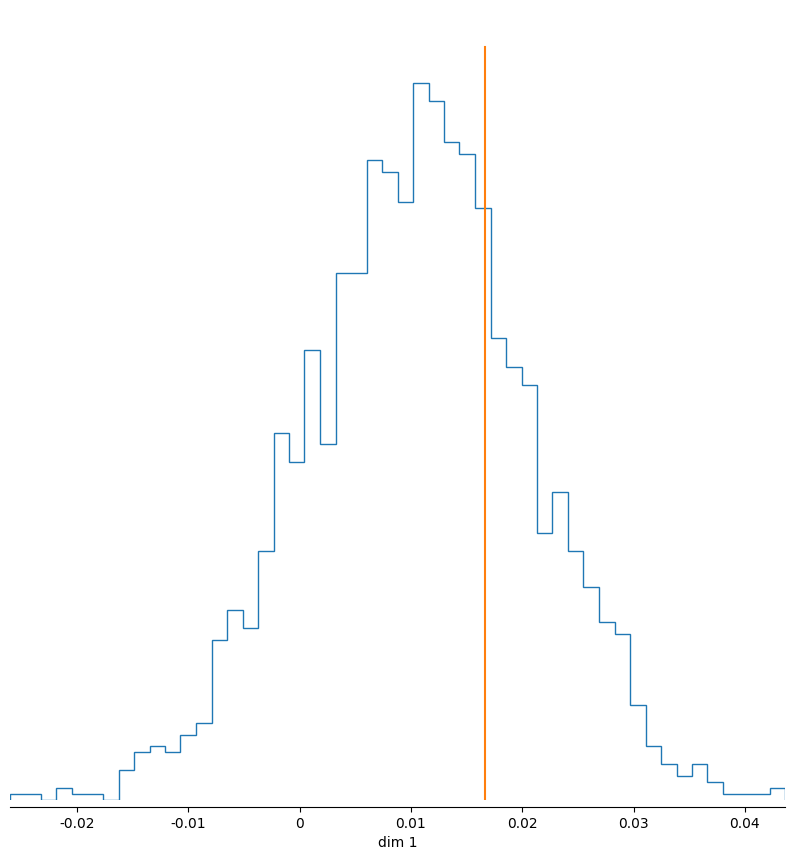

[False False False False] [] [ 0.304  0.536 -0.275  0.242]


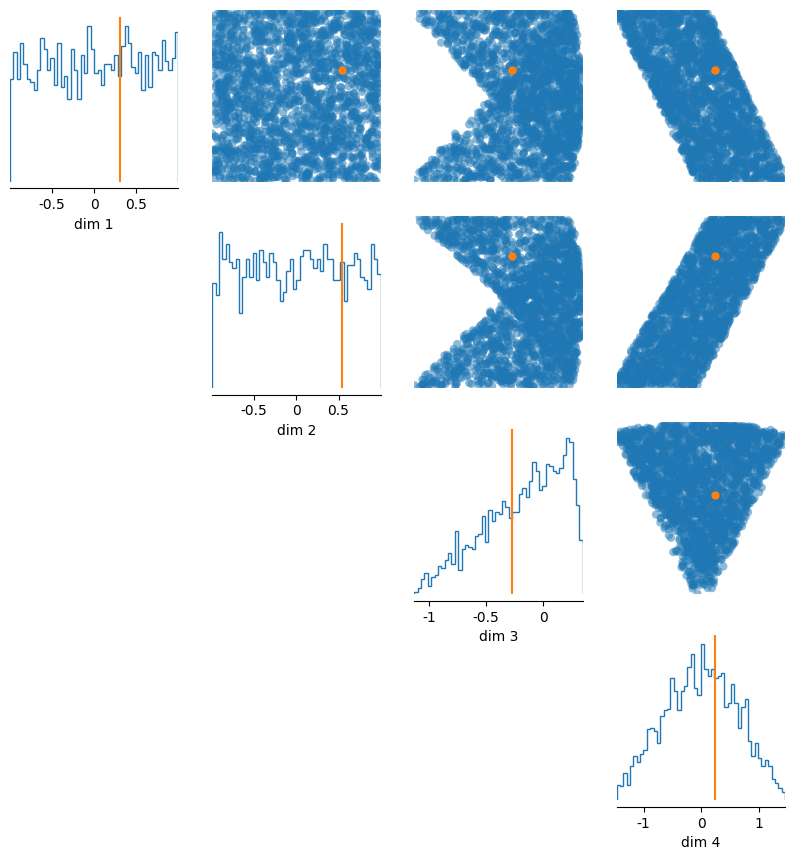

[False False  True  True] [-0.37   0.714] [-0.994  0.014]


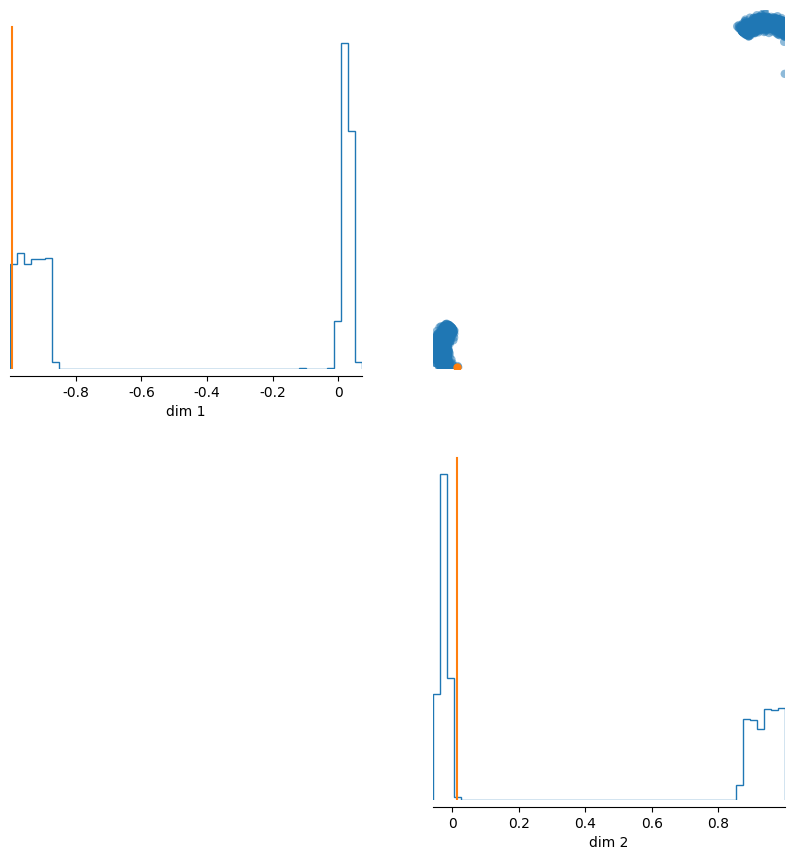

[False  True False  True] [0.873 0.366] [ 0.504 -0.703]


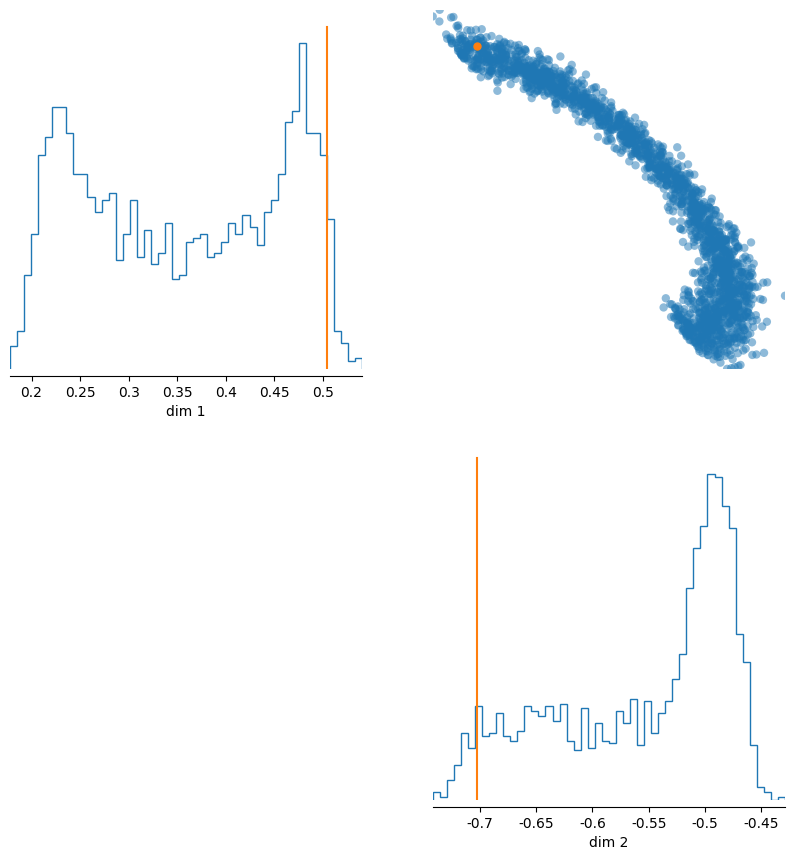

[False False False False] [] [ 0.802  0.597 -0.673 -0.054]


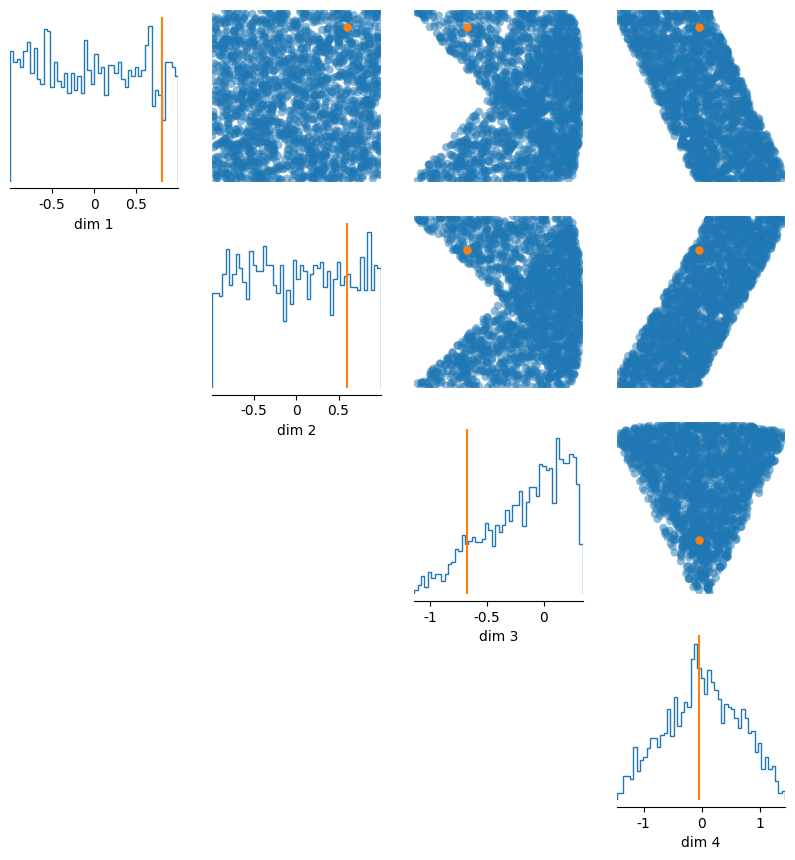

[ True False False False] [-0.457] [-0.155 -0.092  0.191]


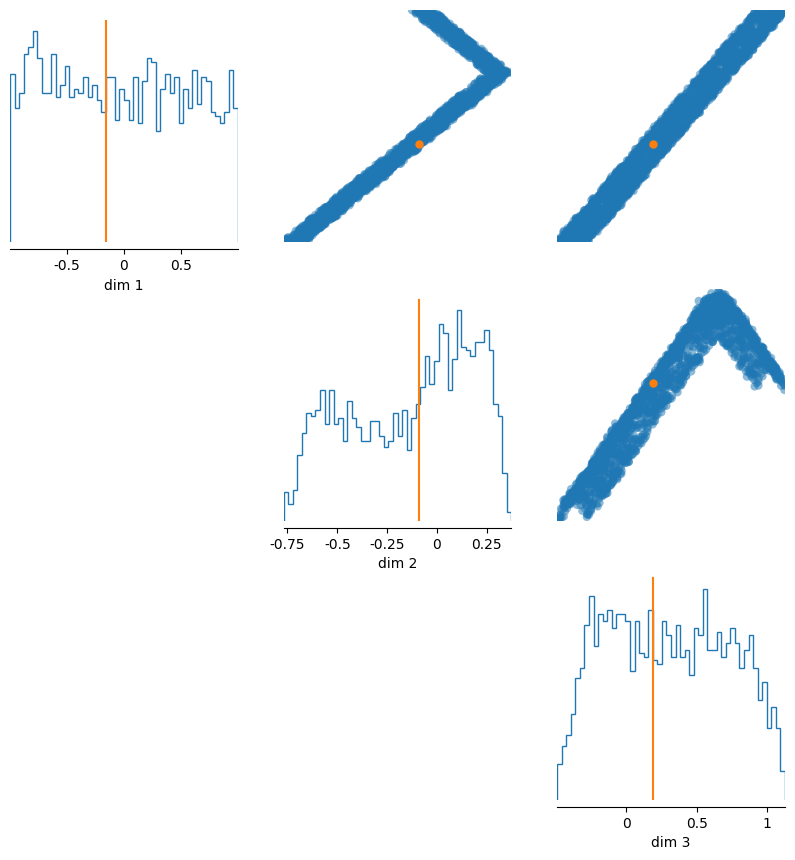

[False False False  True] [0.366] [-0.1    0.345  0.161]


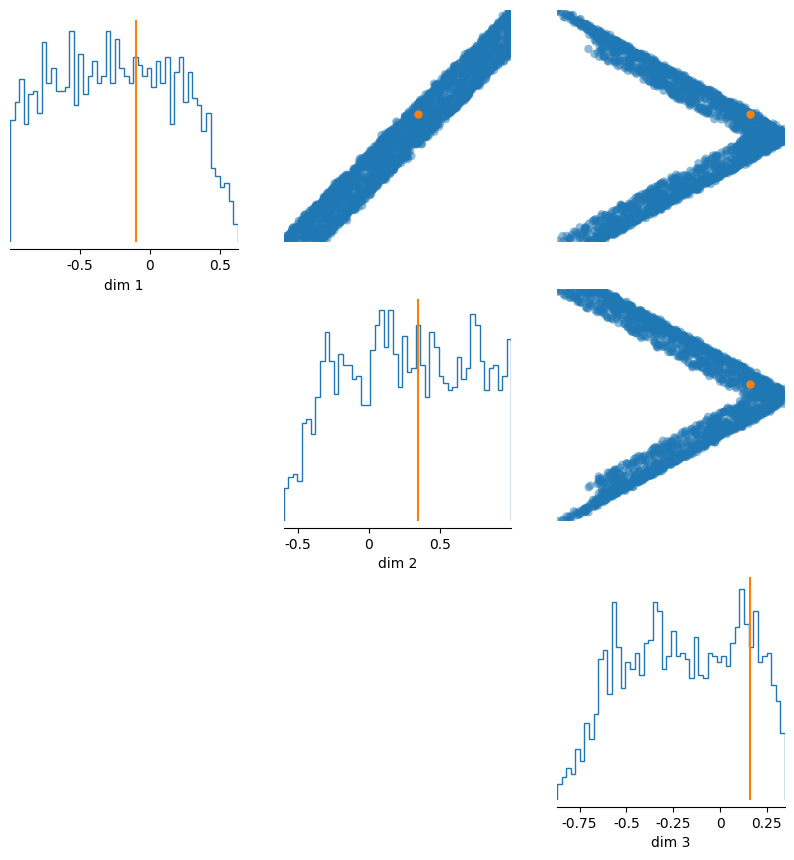

[False False False  True] [0.522] [ 0.105  0.714 -0.285]


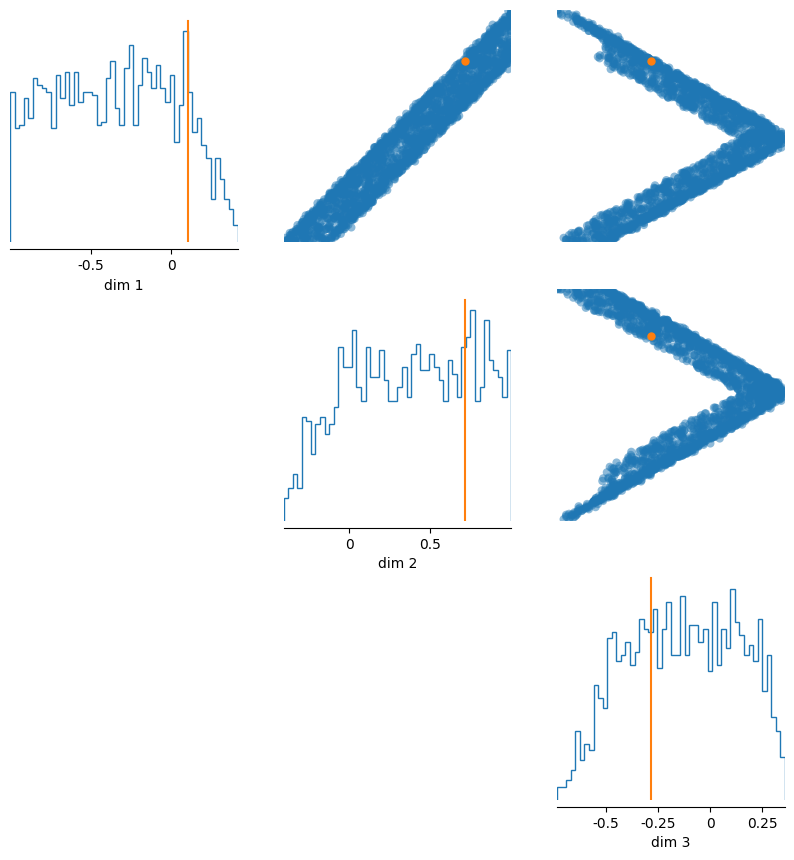

[False  True  True  True] [0.83  0.122 1.11 ] [-0.615]


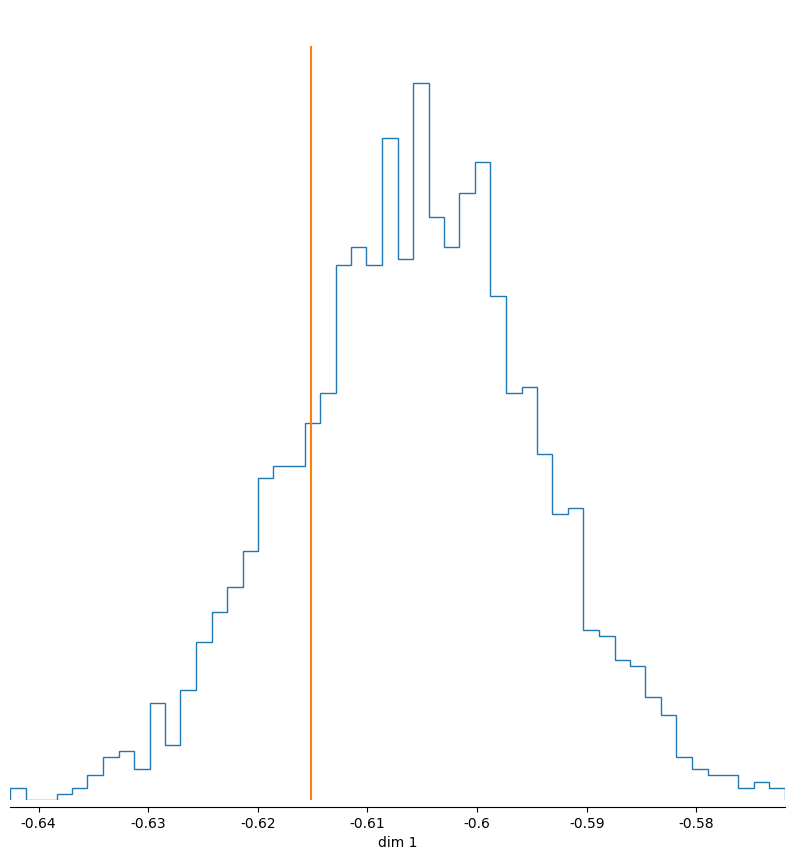

[False  True False  True] [0.757 1.024] [-0.57   0.152]


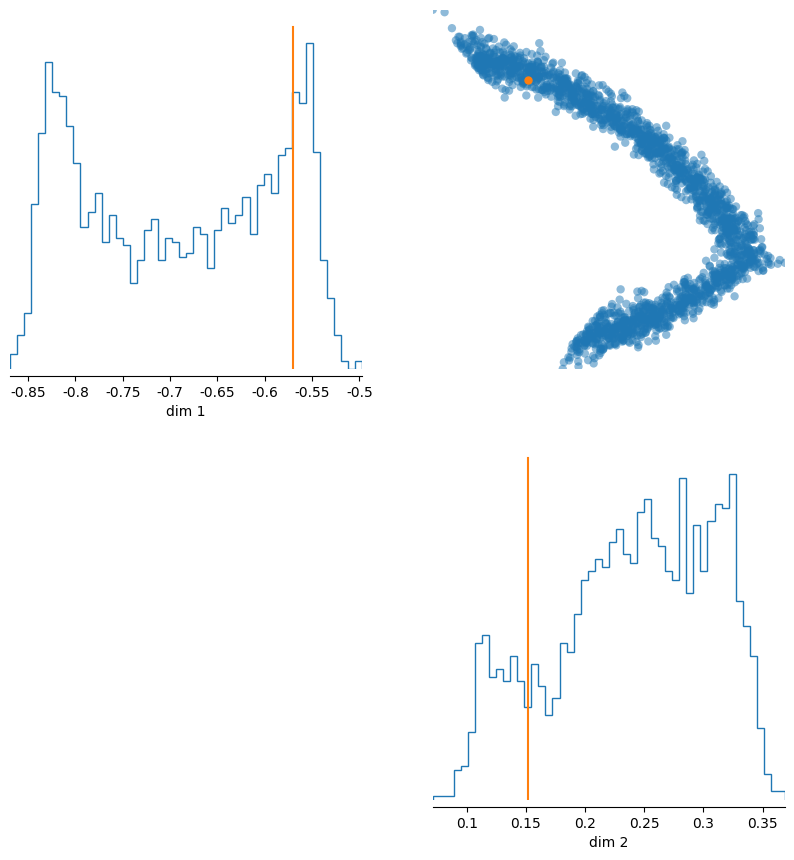

[ True False  True  True] [-0.099 -0.203  0.719] [0.786]


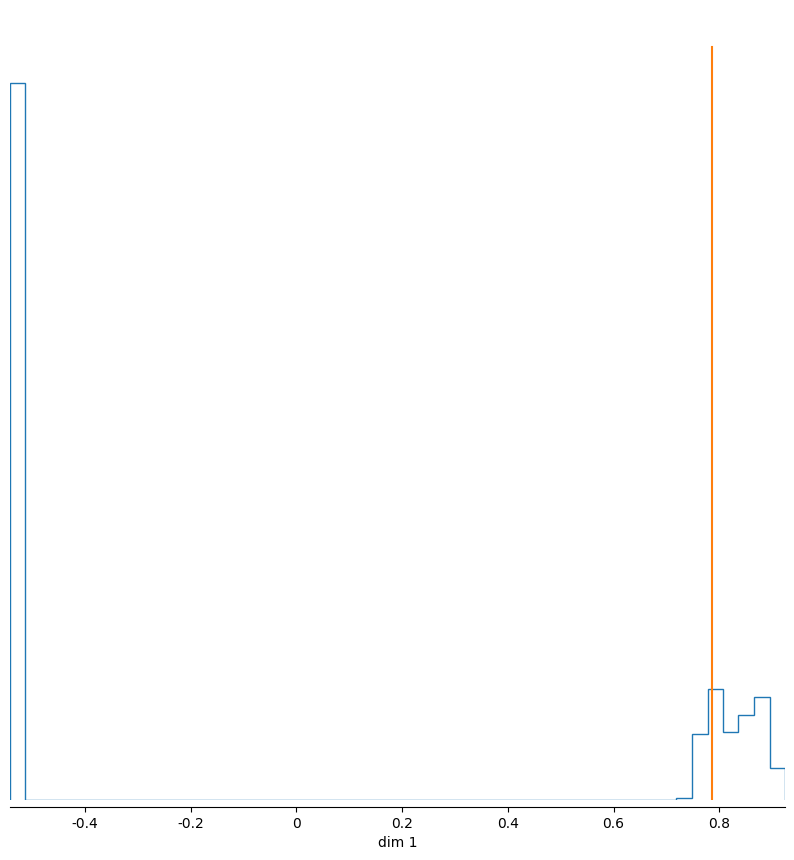

[ True  True False False] [0.357 0.617] [-0.379  0.27 ]


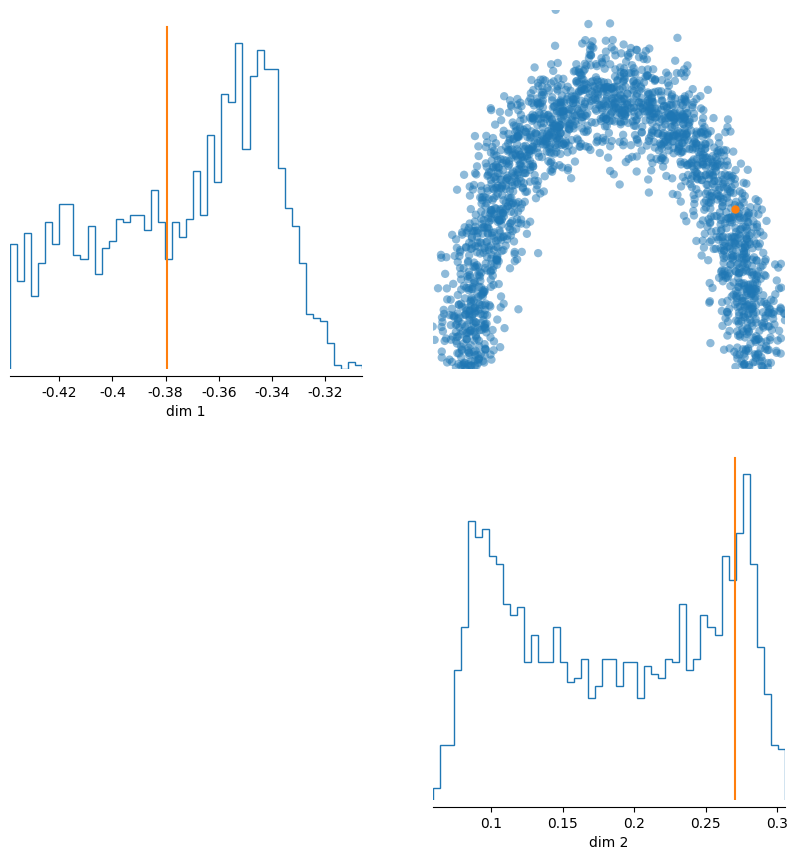

[False False  True False] [-0.435] [-0.818 -0.264  0.357]


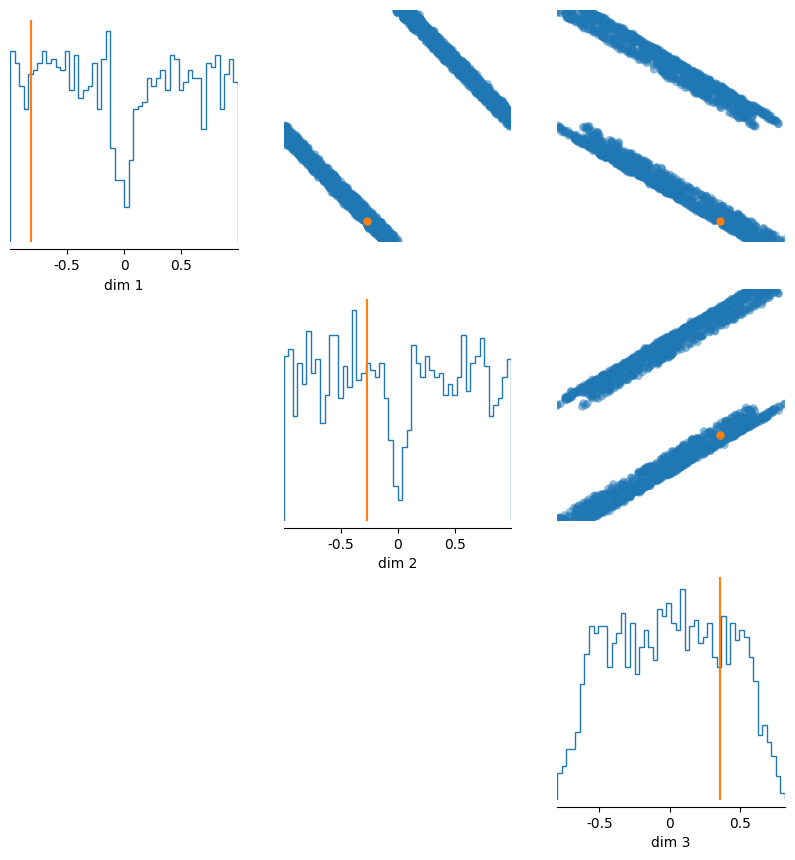

[ True  True  True False] [-0.076 -0.183  0.162] [-0.103]


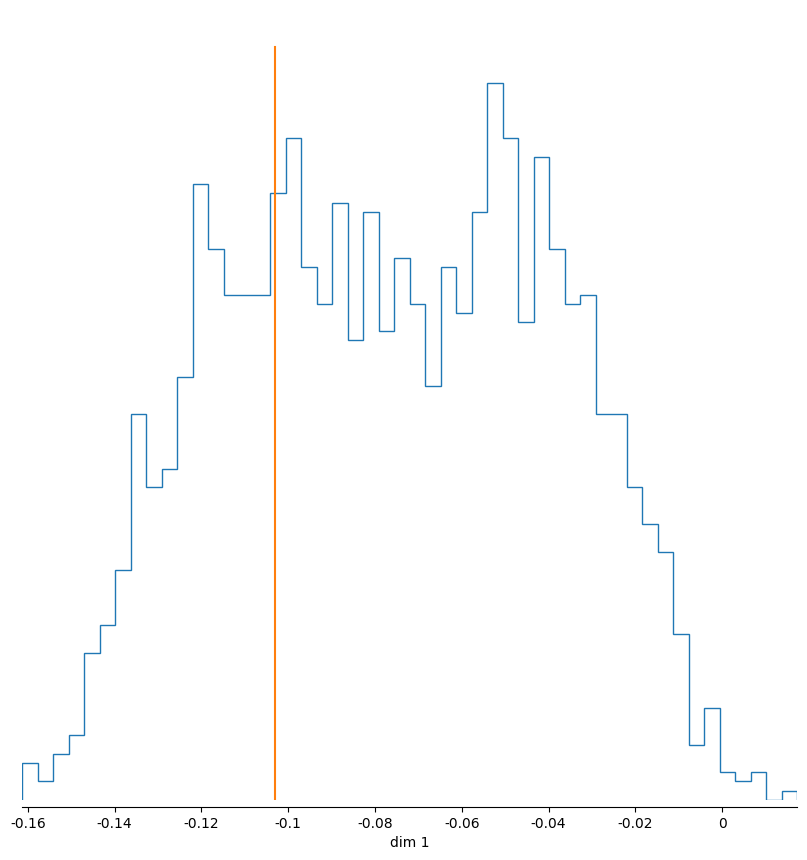

[False False False  True] [0.613] [ 0.08   0.811 -0.35 ]


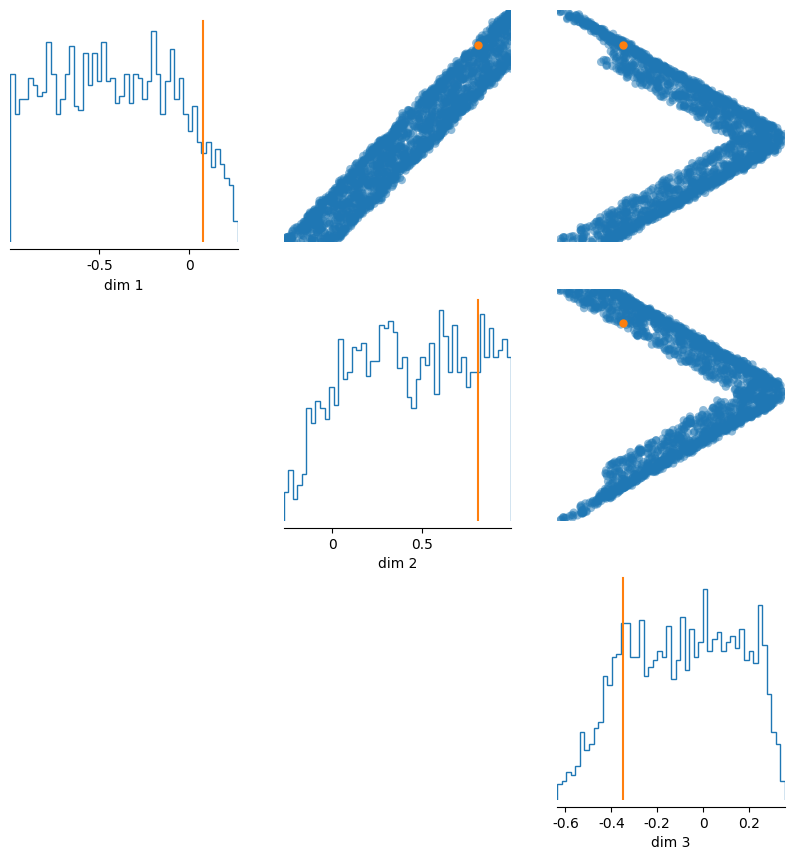

[False False  True  True] [-0.676 -0.121] [0.855 0.559]


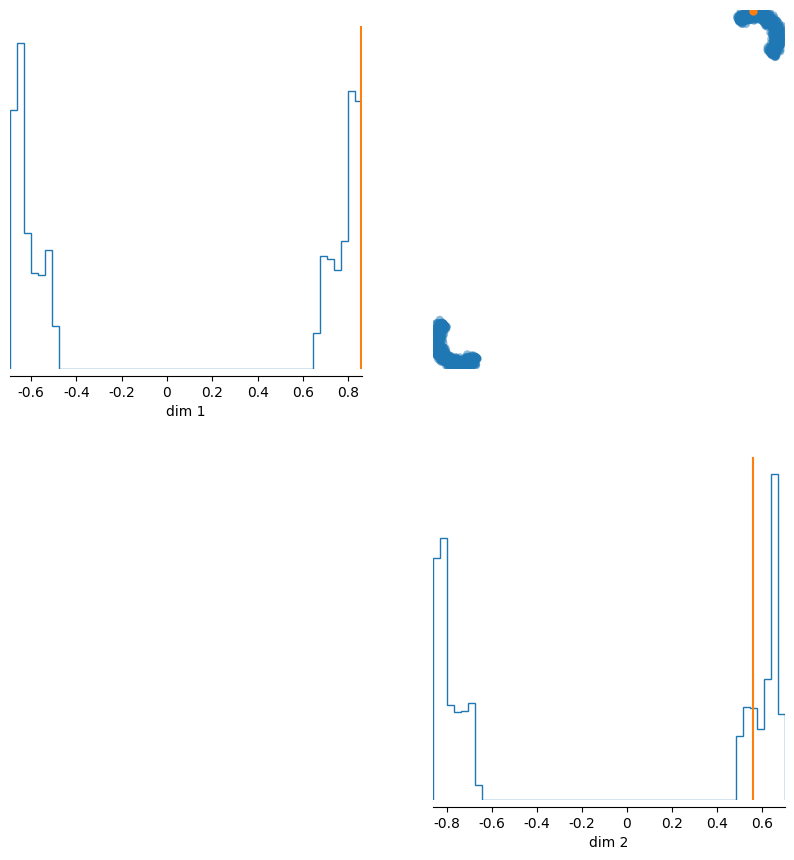

[False  True False  True] [0.925 1.3  ] [-0.79   0.165]


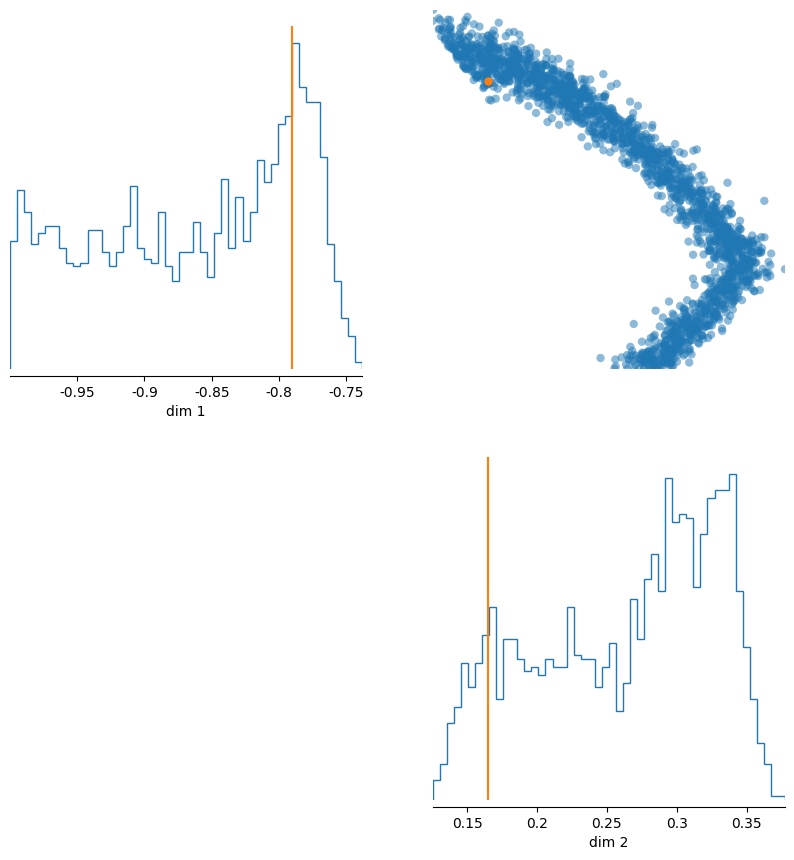

[False  True  True False] [0.253 0.162] [0.002 0.217]


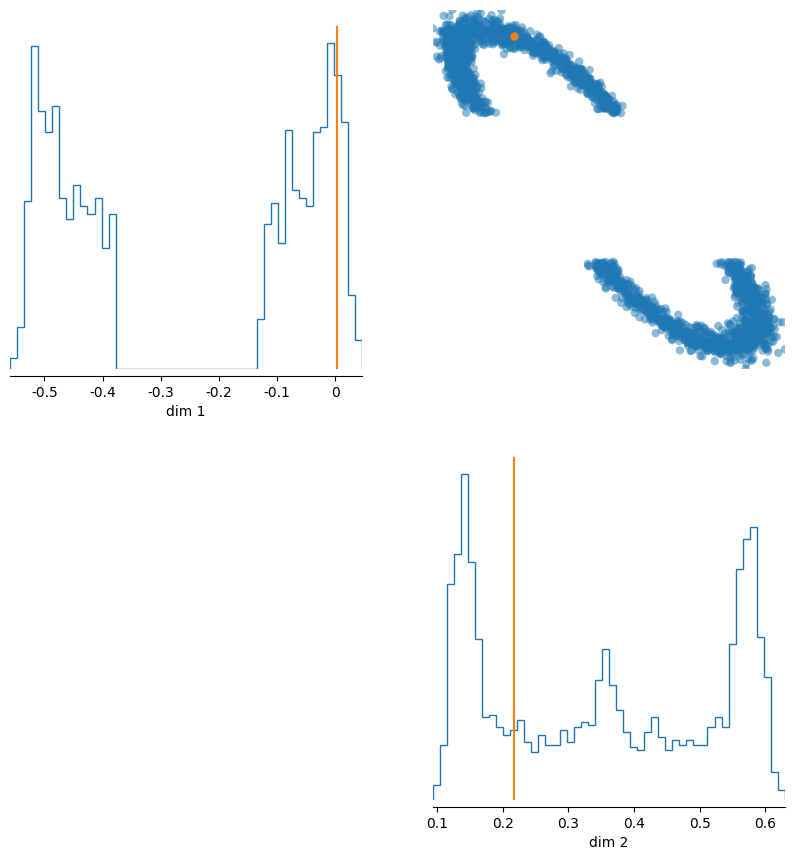

[False  True False  True] [0.909 0.767] [-0.036 -0.353]


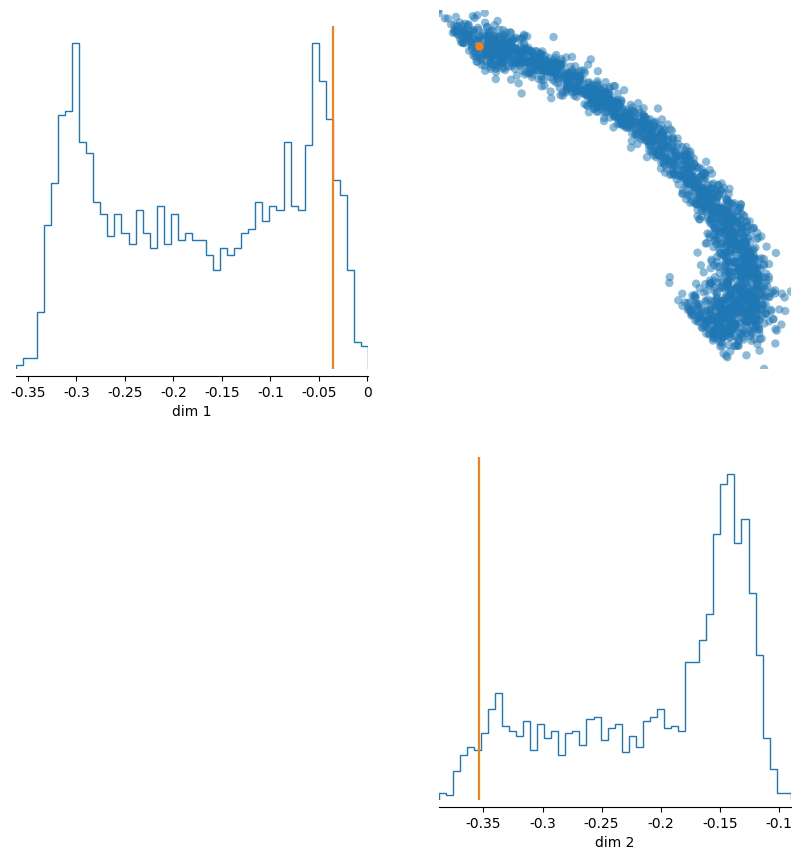

[False  True False  True] [0.612 0.41 ] [ 0.151 -0.231]


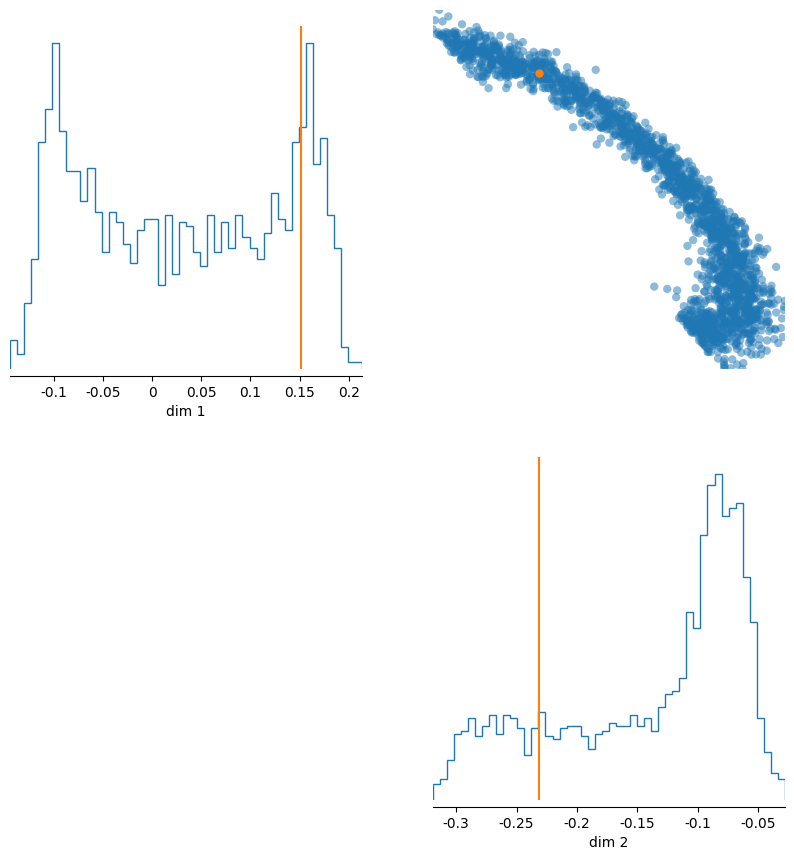

[ True False  True  True] [-0.517 -0.084  1.16 ] [0.991]


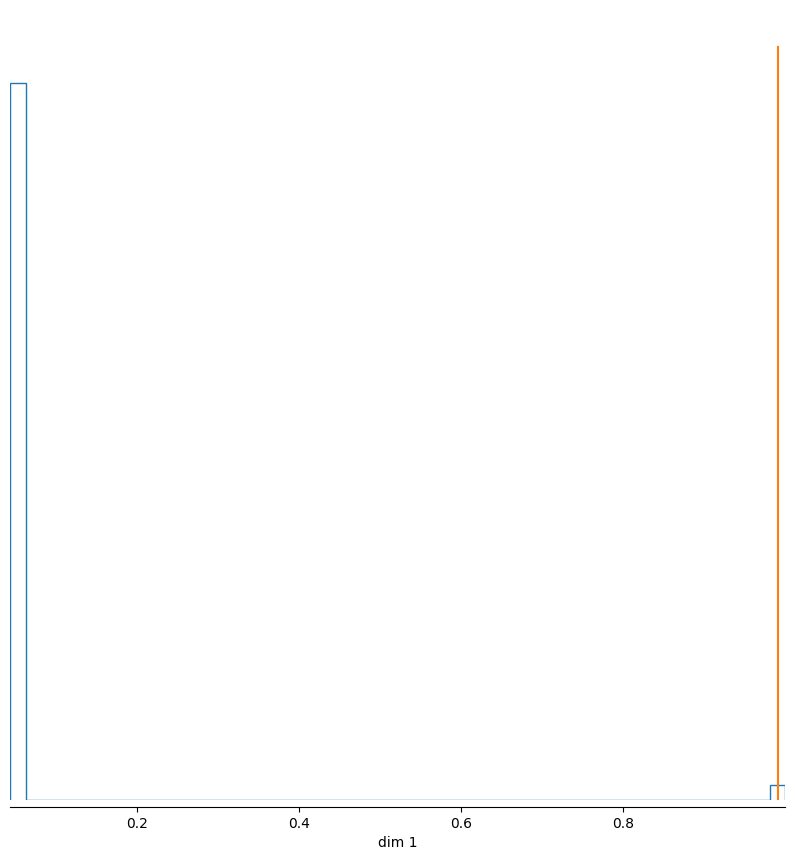

[False  True  True False] [0.618 0.085] [-0.918  1.154]


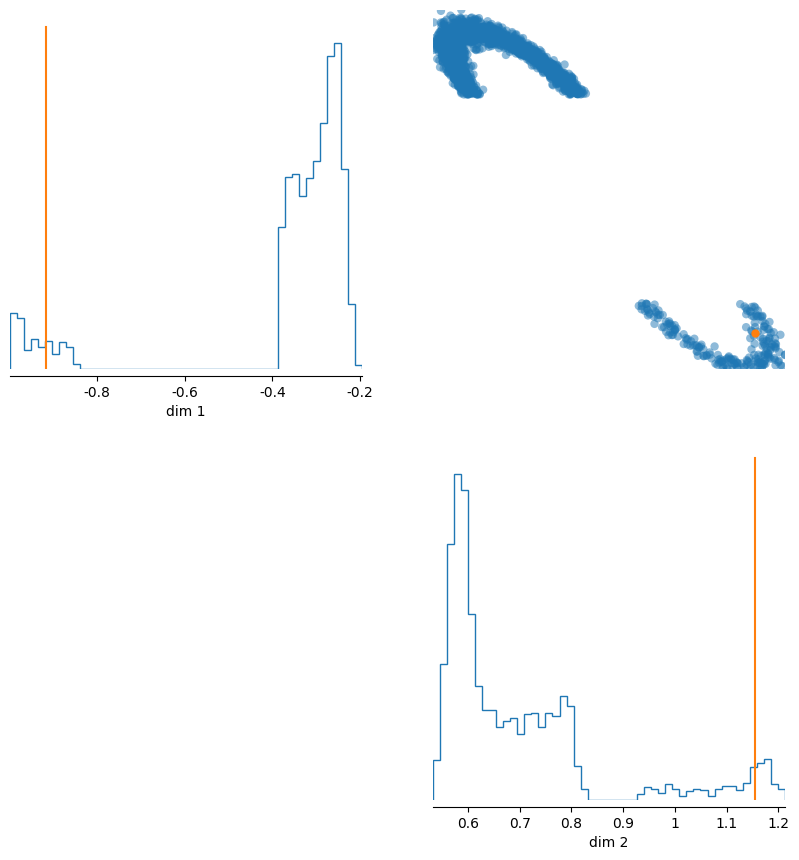

[ True False False False] [0.538] [ 0.439 -0.358 -0.002]


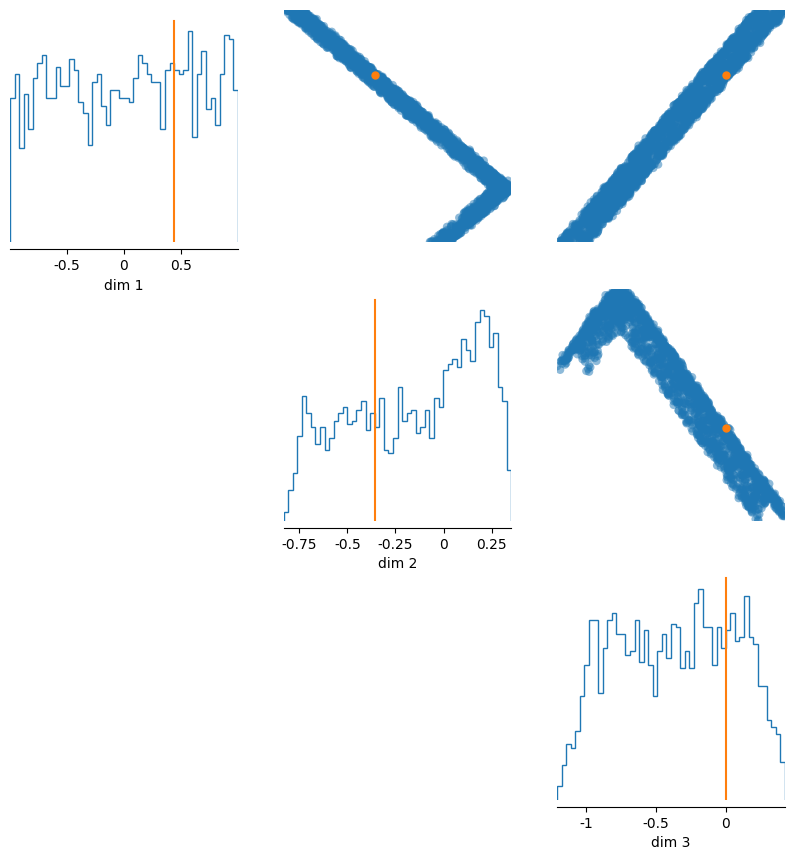

[ True False False  True] [ 0.737 -0.371] [ 0.171 -0.285]


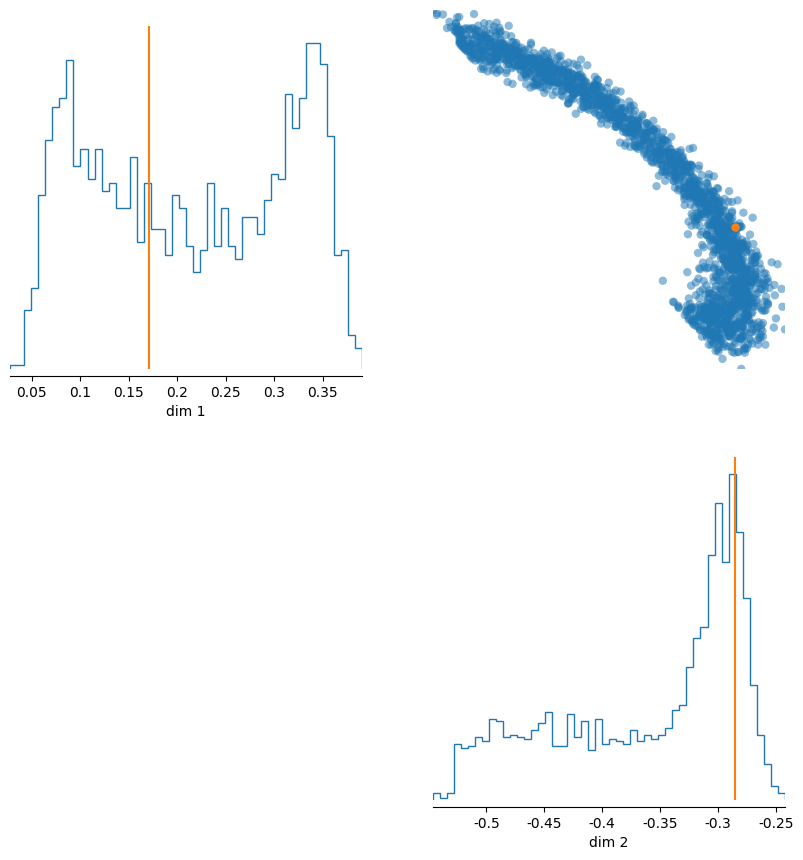

[False False False False] [] [ 0.474 -0.581  0.239 -0.83 ]


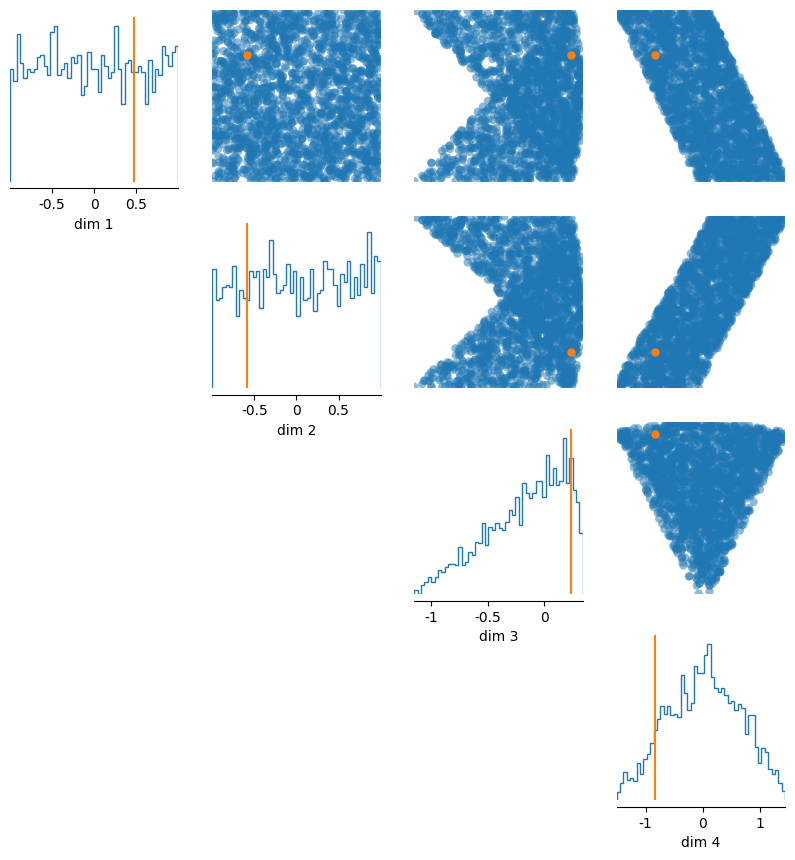

[ True  True  True False] [ 0.493  0.556 -0.423] [0.126]


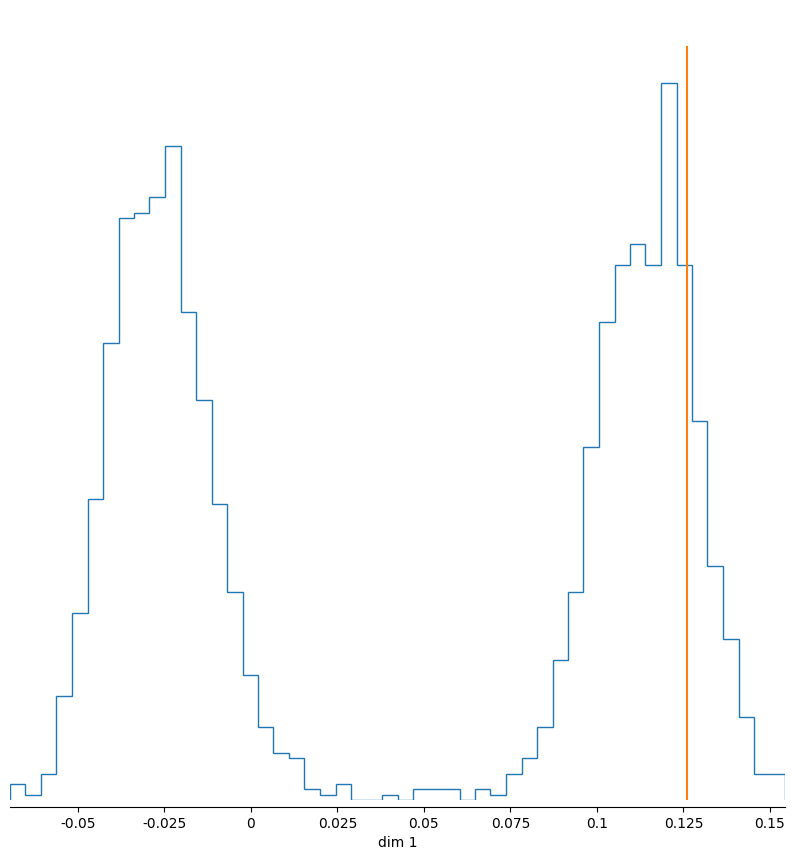

In [12]:
observation_stream = task.get_observation_generator()(jax.random.PRNGKey(3))
for i in range(30):
    # Two moons
    condition_mask, x_o, theta_o = next(observation_stream)
    print(condition_mask, x_o, theta_o)
    # Two moons
    samples = reference_sampler.sample(2000,x_o = x_o, condition_mask=condition_mask, rng=jax.random.PRNGKey(i))
    _ = pairplot(np.array(samples), points=np.array(theta_o), upper="scatter")
    plt.show()